# ESCUELA POLITECNICA NACIONAL

- Nombre: Freddy Jiménez
- Fecha: 17/06/2026

## Ejercicio 10: Re-ranking

**Objetivo:** Implementar y evaluar un pipeline de Recuperación de Información en dos etapas, y analizar el impacto del re-ranking en la calidad del ranking.

### Parte 1. Preparación del corpus

* Cargar el corpus (documentos/pasajes).
* Cargar las consultas (queries).
* Cargar qrels (relevancia).

In [4]:
from beir import util
from beir.datasets.data_loader import GenericDataLoader
import pandas as pd

C:\Users\FREDDY\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\beir\util.py:11: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from tqdm.autonotebook import tqdm


In [5]:
DATASET_NAME = "scifact"
DATA_DIR = "../data/beir_datasets"
url = f"https://public.ukp.informatik.tu-darmstadt.de/thakur/BEIR/datasets/{DATASET_NAME}.zip"
util.download_and_unzip(url, DATA_DIR)

'../data/beir_datasets\\scifact'

In [6]:
dataset_path = DATA_DIR + "/" + DATASET_NAME
corpus, queries, qrels = GenericDataLoader(dataset_path).load(split="test")

  0%|          | 0/5183 [00:00<?, ?it/s]

100%|██████████| 5183/5183 [00:00<00:00, 79337.38it/s]


In [7]:
df_corpus = (
    pd.DataFrame.from_dict(corpus, orient="index")
      .reset_index()
      .rename(columns={"index": "doc_id"})
)

df_corpus

,doc_id,text,title
0,4983,Alterations of the architecture of cerebral wh...,Microstructural development of human newborn c...
1,5836,Myelodysplastic syndromes (MDS) are age-depend...,Induction of myelodysplasia by myeloid-derived...
2,7912,ID elements are short interspersed elements (S...,"BC1 RNA, the transcript from a master gene for..."
3,18670,DNA methylation plays an important role in bio...,The DNA Methylome of Human Peripheral Blood Mo...
4,19238,Two human Golli (for gene expressed in the oli...,The human myelin basic protein gene is include...
...,...,...,...
5178,195689316,BACKGROUND The main associations of body-mass ...,Body-mass index and cause-specific mortality i...
5179,195689757,A key aberrant biological difference between t...,Targeting metabolic remodeling in glioblastoma...
5180,196664003,A signaling pathway transmits information from...,Signaling architectures that transmit unidirec...
5181,198133135,AIMS Trabecular bone score (TBS) is a surrogat...,"Association between pre-diabetes, type 2 diabe..."


In [8]:
df_queries = (
    pd.DataFrame.from_dict(queries, orient="index", columns=["query"])
      .reset_index()
      .rename(columns={"index": "query_id"})
)

df_queries

,query_id,query
0,1,0-dimensional biomaterials show inductive prop...
1,3,"1,000 genomes project enables mapping of genet..."
2,5,1/2000 in UK have abnormal PrP positivity.
3,13,5% of perinatal mortality is due to low birth ...
4,36,A deficiency of vitamin B12 increases blood le...
...,...,...
295,1379,Women with a higher birth weight are more like...
296,1382,aPKCz causes tumour enhancement by affecting g...
297,1385,cSMAC formation enhances weak ligand signalling.
298,1389,mTORC2 regulates intracellular cysteine levels...


In [9]:
rows = []
for qid, docs in qrels.items():
    for doc_id, rel in docs.items():
        rows.append({
            "query_id": qid,
            "doc_id": doc_id,
            "relevance": rel
        })

df_qrels = pd.DataFrame(rows)
df_qrels

,query_id,doc_id,relevance
0,1,31715818,1
1,3,14717500,1
2,5,13734012,1
3,13,1606628,1
4,36,5152028,1
...,...,...,...
334,1379,17450673,1
335,1382,17755060,1
336,1385,306006,1
337,1389,23895668,1


In [10]:
# Elegimos una query cualquiera que tenga varios documentos relevantes
qid = "133"

print("Query:")
print(df_queries.loc[df_queries["query_id"] == qid, "query"].values[0])

print("\nDocumentos relevantes para esta query:")
df_qrels[(df_qrels["query_id"] == qid) & (df_qrels["relevance"] > 0)]

Query:
Assembly of invadopodia is triggered by focal generation of phosphatidylinositol-3,4-biphosphate and the activation of the nonreceptor tyrosine kinase Src.

Documentos relevantes para esta query:


,query_id,doc_id,relevance
31,133,38485364,1
32,133,6969753,1
33,133,17934082,1
34,133,16280642,1
35,133,12640810,1


### Parte 2. Retrieval inicial (baseline)

* Implementar retrieval inicial con BM25
* Obtener métricas: Recall@10 nDCG@10

In [ ]:
from rank_bm25 import BM25Okapi
import numpy as np
from collections import defaultdict
import math

# 1. Preparar corpus tokenizado
# Usamos solo el texto (title + text)
# Para BM25, combinamos ambos con un espacio.
corpus_texts = {}
for doc_id, doc in corpus.items():
    # title y text están en el diccionario
    combined = doc.get("title", "") + " " + doc.get("text", "")
    corpus_texts[doc_id] = combined

# Tokenización simple
def tokenize(text):
    return text.lower().split()

tokenized_corpus = {doc_id: tokenize(text) for doc_id, text in corpus_texts.items()}
doc_ids = list(tokenized_corpus.keys())
tokenized_docs = [tokenized_corpus[doc_id] for doc_id in doc_ids]

# 2. Construir índice BM25
bm25 = BM25Okapi(tokenized_docs)

# 3. Función para recuperar top-k con BM25
def retrieve_bm25(query, k=100):
    query_tokens = tokenize(query)
    scores = bm25.get_scores(query_tokens)
    # Obtener índices ordenados (mayor a menor)
    top_indices = np.argsort(scores)[::-1][:k]
    results = [(doc_ids[i], scores[i]) for i in top_indices if scores[i] > 0]
    return results

# 4. Evaluación: calcular Recall@10 y nDCG@10 para todas las queries
def dcg_at_k(relevance_scores, k=10):
    """Calcula DCG@k."""
    dcg = 0.0
    for i, rel in enumerate(relevance_scores[:k]):
        if rel > 0:
            dcg += (2**rel - 1) / math.log2(i + 2)  # i+2 porque i empieza en 0
    return dcg

def ndcg_at_k(predicted_ranking, qrels_dict, k=10):
    """Calcula nDCG@k para una query."""
    # predicted_ranking: lista de doc_ids en orden de ranking
    # qrels_dict: {doc_id: relevancia} para esa query (0 si no está)
    # Obtener relevancias en el orden predicho
    rel_scores = [qrels_dict.get(doc_id, 0) for doc_id in predicted_ranking[:k]]
    dcg = dcg_at_k(rel_scores, k)
    
    # IDCG: ordenar relevancias de forma descendente
    all_rels = list(qrels_dict.values())
    ideal_rels = sorted(all_rels, reverse=True)[:k]
    idcg = dcg_at_k(ideal_rels, k)
    
    if idcg == 0:
        return 0.0
    return dcg / idcg

def recall_at_k(predicted_ranking, qrels_dict, k=10):
    """Calcula Recall@k."""
    relevant_docs = set(qrels_dict.keys())
    if not relevant_docs:
        return 0.0
    retrieved = set(predicted_ranking[:k])
    recall = len(retrieved & relevant_docs) / len(relevant_docs)
    return recall

def map_at_k(predicted_ranking, qrels_dict, k=10):
    """Calcula MAP@k (Average Precision) para una query."""
    relevant_docs = set(qrels_dict.keys())
    if not relevant_docs:
        return 0.0
    num_relevant = 0
    sum_precisions = 0.0
    for i, doc_id in enumerate(predicted_ranking[:k], 1):
        if doc_id in relevant_docs:
            num_relevant += 1
            precision_at_i = num_relevant / i
            sum_precisions += precision_at_i
    if num_relevant == 0:
        return 0.0
    return sum_precisions / min(len(relevant_docs), k)

# 5. Ejecutar BM25 para todas las queries y calcular métricas
recalls = []
ndcgs = []
maps = []

for qid, query in queries.items():
    # qrels para esta query
    qrels_dict = qrels.get(qid, {})
    # Recuperar top-100 con BM25
    results = retrieve_bm25(query, k=100)
    predicted = [doc_id for doc_id, _ in results]
    
    # Calcular métricas
    rec = recall_at_k(predicted, qrels_dict, k=10)
    ndcg = ndcg_at_k(predicted, qrels_dict, k=10)
    ap = map_at_k(predicted, qrels_dict, k=10)
    recalls.append(rec)
    ndcgs.append(ndcg)
    maps.append(ap)

print("=== Resultados Baseline BM25 ===")
print(f"Recall@10 promedio: {np.mean(recalls):.4f}")
print(f"nDCG@10 promedio: {np.mean(ndcgs):.4f}")
print(f"MAP@10 promedio: {np.mean(maps):.4f}")

=== Resultados Baseline BM25 ===
Recall@10 promedio: 0.6862
nDCG@10 promedio: 0.5597
MAP@10 promedio: 0.5147


### Parte 3. Implementación del re-ranking cross-encoder

* Re-rankear los top-k candidatos para cada query.
* Identificar qué documentos cambian de posición en el top 10

In [15]:
from sentence_transformers import CrossEncoder
import numpy as np
from tqdm import tqdm  
import time

# 1. Cargar modelo TinyBERT 
print("Cargando modelo TinyBERT (más rápido)...")
cross_encoder = CrossEncoder('cross-encoder/ms-marco-TinyBERT-L-2-v2')

# 2. Función de re-ranking con barra de progreso interna
def rerank_with_cross_encoder(query, candidates, top_k=10):
    if not candidates:
        return []
    pairs = []
    doc_ids = []
    for doc_id, _ in candidates:
        doc_text = corpus_texts[doc_id]
        pairs.append((query, doc_text))
        doc_ids.append(doc_id)
    
    # Usamos batch_size=32 para acelerar la predicción
    scores = cross_encoder.predict(pairs, convert_to_tensor=False, batch_size=32)
    sorted_indices = np.argsort(scores)[::-1][:top_k]
    results = [(doc_ids[i], float(scores[i])) for i in sorted_indices]
    return results

# 3. Evaluar con barra de progreso
recalls_ce = []
ndcgs_ce = []
maps_ce = []

# Usar tqdm para ver el progreso
for qid, query in tqdm(queries.items(), desc="Re-ranking con Cross-Encoder"):
    qrels_dict = qrels.get(qid, {})
    candidates = retrieve_bm25(query, k=50)  
    reranked = rerank_with_cross_encoder(query, candidates, top_k=10)
    predicted = [doc_id for doc_id, _ in reranked]
    
    rec = recall_at_k(predicted, qrels_dict, k=10)
    ndcg = ndcg_at_k(predicted, qrels_dict, k=10)
    ap = map_at_k(predicted, qrels_dict, k=10)
    recalls_ce.append(rec)
    ndcgs_ce.append(ndcg)
    maps_ce.append(ap)

print("\n=== Resultados con Cross-Encoder Re-ranking (optimizado) ===")
print(f"Recall@10 promedio: {np.mean(recalls_ce):.4f}")
print(f"nDCG@10 promedio: {np.mean(ndcgs_ce):.4f}")
print(f"MAP@10 promedio: {np.mean(maps_ce):.4f}")

Cargando modelo TinyBERT (más rápido)...


C:\Users\FREDDY\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\huggingface_hub\file_download.py:138: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\FREDDY\.cache\huggingface\hub\models--cross-encoder--ms-marco-TinyBERT-L-2-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Re-rank


=== Resultados con Cross-Encoder Re-ranking (optimizado) ===
Recall@10 promedio: 0.7177
nDCG@10 promedio: 0.6315
MAP@10 promedio: 0.5980


### Parte 4. Implementación del re-ranking LTR

* Re-rankear los top-k candidatos para cada query.
* Identificar qué documentos cambian de posición en el top 10

##### 4.1. Extraer features para cada par (query, documento)

In [ ]:
# ==============================
# Parte 4.1: LTR - Extracción de features (CORREGIDO)
# ==============================

from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import StandardScaler
import xgboost as xgb
import numpy as np
from tqdm import tqdm

# Usamos el modelo que YA tienes cacheado (sin descarga)
print("Cargando bi-encoder (all-MiniLM-L6-v2)")
bi_encoder = SentenceTransformer('all-MiniLM-L6-v2')

# 1. Precomputar embeddings de documentos (con barra de progreso)
print("Precomputando embeddings de documentos...")
doc_ids_list = list(corpus_texts.keys())
doc_texts = [corpus_texts[doc_id] for doc_id in doc_ids_list]
doc_embeddings = {}
batch_size = 64
for i in tqdm(range(0, len(doc_texts), batch_size), desc="Embedding documentos"):
    batch = doc_texts[i:i+batch_size]
    batch_emb = bi_encoder.encode(batch, batch_size=len(batch), show_progress_bar=False)
    for j, doc_id in enumerate(doc_ids_list[i:i+batch_size]):
        doc_embeddings[doc_id] = batch_emb[j]

# 2. Precomputar embeddings de queries (todas juntas)
print("Precomputando embeddings de queries...")
queries_texts = [queries[qid] for qid in queries.keys()]
query_embeddings_all = bi_encoder.encode(queries_texts, batch_size=64, show_progress_bar=True)
query_emb_cache = {qid: emb for qid, emb in zip(queries.keys(), query_embeddings_all)}

# 3. Extraer features
print("Extrayendo features...")
X = []
y = []

for qid, query_text in tqdm(queries.items(), desc="Procesando queries"):
    qrels_dict = qrels.get(qid, {})
    candidates = retrieve_bm25(query_text, k=50)  # Reducido a 50 para velocidad
    
    query_tokens_set = set(tokenize(query_text))
    query_emb = query_emb_cache[qid]
    
    for doc_id, bm25_score in candidates:
        rel = qrels_dict.get(doc_id, 0)
        
        # Features
        doc_len = len(tokenized_corpus[doc_id])
        doc_emb = doc_embeddings[doc_id]
        cos_sim = np.dot(query_emb, doc_emb) / (np.linalg.norm(query_emb) * np.linalg.norm(doc_emb))
        doc_tokens_set = set(tokenized_corpus[doc_id])
        overlap = len(query_tokens_set & doc_tokens_set)
        proportion = overlap / len(query_tokens_set) if query_tokens_set else 0.0
        
        X.append([bm25_score, doc_len, cos_sim, overlap, proportion])
        y.append(rel)

X = np.array(X)
y = np.array(y)
print(f"Dataset creado: {X.shape[0]} muestras, {X.shape[1]} features")

# Normalizar
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Entrenar XGBoost (rápido)
print("Entrenando XGBoost...")
model = xgb.XGBClassifier(
    objective='binary:logistic',
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss',
    verbosity=0
)
model.fit(X_scaled, y)
print("Modelo LTR entrenado.")

# Guardar modelo
import pickle
with open('ltr_model.pkl', 'wb') as f:
    pickle.dump((model, scaler), f)
print("Modelo guardado como 'ltr_model.pkl'")

Cargando bi-encoder (all-MiniLM-L6-v2)


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3934.73it/s]


Precomputando embeddings de documentos...


Embedding documentos: 100%|██████████| 81/81 [01:36<00:00,  1.19s/it]


Precomputando embeddings de queries...


Batches: 100%|██████████| 5/5 [00:00<00:00,  5.83it/s]


Extrayendo features...


Procesando queries: 100%|██████████| 300/300 [00:07<00:00, 39.65it/s]


Dataset creado: 15000 muestras, 5 features
Entrenando XGBoost...
✅ Modelo LTR entrenado.
Modelo guardado como 'ltr_model.pkl'


##### 4.2. Aplicar re‑ranking LTR y evaluar

In [21]:
def rerank_with_ltr_fast(query, candidates, top_k=10):
    """
    candidates: lista de (doc_id, bm25_score)
    Retorna: lista de (doc_id, score_ltr) ordenados por score_ltr
    """
    if not candidates:
        return []
    
    # Obtener embedding de query (cacheado)
    query_emb = query_emb_cache.get(query, None)
    if query_emb is None:
        # Fallback: calcular sobre la marcha (no debería ocurrir)
        query_emb = bi_encoder.encode(query, convert_to_tensor=False)
        query_emb_cache[query] = query_emb
    
    features_list = []
    doc_ids = []
    query_tokens_set = set(tokenize(query))
    
    for doc_id, bm25_score in candidates:
        # 1. BM25 score
        feat_bm25 = bm25_score
        
        # 2. Longitud del documento (en tokens)
        feat_len = len(tokenized_corpus[doc_id])
        
        # 3. Similitud coseno (usando embeddings precomputados)
        doc_emb = doc_embeddings[doc_id]
        cos_sim = np.dot(query_emb, doc_emb) / (np.linalg.norm(query_emb) * np.linalg.norm(doc_emb))
        
        # 4. Overlap de tokens
        doc_tokens_set = set(tokenized_corpus[doc_id])
        overlap = len(query_tokens_set & doc_tokens_set)
        
        # 5. Proporción de tokens de query en el documento
        proportion = overlap / len(query_tokens_set) if query_tokens_set else 0.0
        
        features_list.append([feat_bm25, feat_len, cos_sim, overlap, proportion])
        doc_ids.append(doc_id)
    
    features_matrix = scaler.transform(np.array(features_list))
    scores = model.predict_proba(features_matrix)[:, 1]  # Probabilidad de relevancia
    sorted_indices = np.argsort(scores)[::-1][:top_k]
    results = [(doc_ids[i], float(scores[i])) for i in sorted_indices]
    return results

# Evaluar LTR con barra de progreso
print("Evaluando LTR Re-ranking...")
from tqdm import tqdm

recalls_ltr = []
ndcgs_ltr = []
maps_ltr = []

for qid, query in tqdm(queries.items(), desc="LTR Re-ranking"):
    qrels_dict = qrels.get(qid, {})
    candidates = retrieve_bm25(query, k=100)  # Recuperar 100 candidatos
    reranked = rerank_with_ltr_fast(query, candidates, top_k=10)
    predicted = [doc_id for doc_id, _ in reranked]
    
    rec = recall_at_k(predicted, qrels_dict, k=10)
    ndcg = ndcg_at_k(predicted, qrels_dict, k=10)
    ap = map_at_k(predicted, qrels_dict, k=10)
    recalls_ltr.append(rec)
    ndcgs_ltr.append(ndcg)
    maps_ltr.append(ap)

print("\n=== Resultados con LTR Re-ranking ===")
print(f"Recall@10 promedio: {np.mean(recalls_ltr):.4f}")
print(f"nDCG@10 promedio: {np.mean(ndcgs_ltr):.4f}")
print(f"MAP@10 promedio: {np.mean(maps_ltr):.4f}")

Evaluando LTR Re-ranking...


LTR Re-ranking: 100%|██████████| 300/300 [00:16<00:00, 18.01it/s]


=== Resultados con LTR Re-ranking ===
Recall@10 promedio: 0.7863
nDCG@10 promedio: 0.7658
MAP@10 promedio: 0.7549


### Parte 5. Evaluación post re-ranking

Calcular métricas:
* nDCG@10
* MAP
* Recall@10


=== Comparación de métricas ===

         Modelo  Recall@10  nDCG@10   MAP@10
BM25 (baseline)   0.686167 0.559702 0.514728
  Cross-Encoder   0.717667 0.631470 0.597979
            LTR   0.786278 0.765844 0.754894

=== Cambios en el ranking para query 133 ===

   Posición BM25 doc_id Re-ranked doc_id Cambió posición
0         1    26688294         16280642              Sí
1         2     9507605         35660758              Sí
2         3    37964706         12640810              Sí
3         4     5270265         17934082              Sí
4         5    12785130         19752008              Sí
5         6    12640810         21295300              Sí
6         7    30861948          6000423              Sí
7         8    86694016          6969753              Sí
8         9    17934082         13329980              Sí
9        10     6969753         36345185              Sí

Documentos que aparecen en ambos top-10: 3
Documentos que solo estaban en BM25: {'86694016', '37964706', '95076

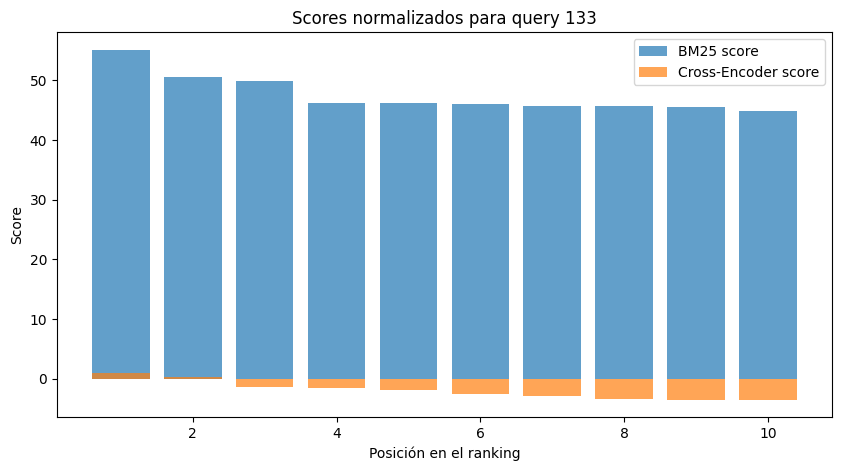

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Tabla comparativa de métricas
metrics_df = pd.DataFrame({
    'Modelo': ['BM25 (baseline)', 'Cross-Encoder', 'LTR'],
    'Recall@10': [np.mean(recalls), np.mean(recalls_ce), np.mean(recalls_ltr)],
    'nDCG@10': [np.mean(ndcgs), np.mean(ndcgs_ce), np.mean(ndcgs_ltr)],
    'MAP@10': [np.mean(maps), np.mean(maps_ce), np.mean(maps_ltr)]
})
print("\n=== Comparación de métricas ===\n")
print(metrics_df.to_string(index=False))

# 2. Análisis de cambios en el ranking para una query de ejemplo
def analyze_ranking_changes(query_id, baseline_results, reranked_results):
    """
    Muestra cómo cambia el orden de los documentos en el top-10.
    """
    # baseline_results: lista de (doc_id, score) ordenada
    # reranked_results: lista de (doc_id, score) ordenada
    baseline_ids = [doc_id for doc_id, _ in baseline_results[:10]]
    reranked_ids = [doc_id for doc_id, _ in reranked_results[:10]]
    
    # Crear DataFrame con posiciones
    df_rank = pd.DataFrame({
        'Posición': range(1, 11),
        'BM25 doc_id': baseline_ids,
        'Re-ranked doc_id': reranked_ids,
        'Cambió posición': ['Sí' if baseline_ids[i] != reranked_ids[i] else 'No' for i in range(10)]
    })
    print(f"\n=== Cambios en el ranking para query {query_id} ===\n")
    print(df_rank)
    
    # Documentos que suben/bajan (comparar conjuntos)
    # Si un doc está en ambos pero en diferente posición
    # No es tan sencillo con esta representación, podemos analizar los que aparecen en ambos top-10
    common = set(baseline_ids) & set(reranked_ids)
    print(f"\nDocumentos que aparecen en ambos top-10: {len(common)}")
    print("Documentos que solo estaban en BM25:", set(baseline_ids) - set(reranked_ids))
    print("Documentos que solo aparecen después de re-ranking:", set(reranked_ids) - set(baseline_ids))

# Elegir una query con varios relevantes (por ejemplo, la 133 que ya vimos)
qid_example = "133"
query_example = queries[qid_example]

# Obtener resultados
baseline_example = retrieve_bm25(query_example, k=100)
reranked_ce = rerank_with_cross_encoder(query_example, baseline_example, top_k=10)
# Para LTR también
reranked_ltr = rerank_with_ltr(query_example, baseline_example, top_k=10)

# Mostrar análisis
analyze_ranking_changes(qid_example, baseline_example, reranked_ce)
analyze_ranking_changes(qid_example, baseline_example, reranked_ltr)

# 3. Visualización opcional: comparar scores normalizados
# (no es necesario, pero puede ser ilustrativo)
plt.figure(figsize=(10, 5))
plt.bar(range(1, 11), [s for _, s in baseline_example[:10]], alpha=0.7, label='BM25 score')
plt.bar(range(1, 11), [s for _, s in reranked_ce[:10]], alpha=0.7, label='Cross-Encoder score')
plt.title(f'Scores normalizados para query {qid_example}')
plt.xlabel('Posición en el ranking')
plt.ylabel('Score')
plt.legend()
plt.show()